# Modèles de Machine Learning

**Projet BI 25/26 — Groupe 2 & 7**


---



Le churn est **calculé depuis les activités réelles** : un client est churné si sa dernière visite ET son dernier achat datent de plus de **90 jours**.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble        import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics         import (classification_report, confusion_matrix,
                                      roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing  import LabelEncoder

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)

df_purchased = pd.read_csv('dataset/cleaned/df_purchased.csv')
df_churn     = pd.read_csv('dataset/cleaned/df_churn.csv')

print('Données chargées')
print(f'  df_purchased : {df_purchased.shape} | Taux achat  : {df_purchased["purchased"].mean():.1%}')
print(f'  df_churn     : {df_churn.shape}     | Taux churn  : {df_churn["churn"].mean():.1%}')

Données chargées
  df_purchased : (215913, 16) | Taux achat  : 27.8%
  df_churn     : (49661, 22)     | Taux churn  : 19.1%


---
## MODÈLE 1 — Prédiction d'Achat (PURCHASED)

**Question :** Est-ce que cette session va aboutir à un achat ?

In [2]:
# Variables explicatives
features_p = [
    'session_duration_sec',
    'pages_viewed',
    'nb_transactions',
    'avg_product_price',
    'avg_purchase_amount',
    'returns',
    'traffic_source',
    'device',
    'gender',
    'payment_method'
]
target_p = 'purchased'

df_p = df_purchased[features_p + [target_p]].copy()

# Encodage des variables catégorielles
cat_cols_p = ['traffic_source', 'device', 'gender', 'payment_method']
le = LabelEncoder()
for col in cat_cols_p:
    df_p[col] = df_p[col].fillna('Unknown')
    df_p[col] = le.fit_transform(df_p[col].astype(str))

df_p = df_p.dropna()
print(f'Shape après nettoyage : {df_p.shape}')
print(f"Taux d'achat          : {df_p[target_p].mean():.1%}")

Shape après nettoyage : (184635, 11)
Taux d'achat          : 29.3%


In [3]:
X_p = df_p[features_p]
y_p = df_p[target_p]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_p, y_p, test_size=0.2, random_state=42, stratify=y_p
)
print(f'Train : {X_train_p.shape} | Test : {X_test_p.shape}')

rf_p = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_p.fit(X_train_p, y_train_p)
print('Modèle PURCHASED entraîné ')

Train : (147708, 10) | Test : (36927, 10)
Modèle PURCHASED entraîné 


In [4]:
y_pred_p  = rf_p.predict(X_test_p)
y_proba_p = rf_p.predict_proba(X_test_p)[:, 1]

print('=== Classification Report — PURCHASED ===')
print(classification_report(y_test_p, y_pred_p, target_names=["Pas d'achat", 'Achat']))
print(f'ROC-AUC Score : {roc_auc_score(y_test_p, y_proba_p):.4f}')

# Validation croisée
cv_scores = cross_val_score(rf_p, X_p, y_p, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'Cross-validation AUC : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

=== Classification Report — PURCHASED ===
              precision    recall  f1-score   support

 Pas d'achat       0.97      0.96      0.97     26100
       Achat       0.92      0.93      0.92     10827

    accuracy                           0.96     36927
   macro avg       0.94      0.95      0.95     36927
weighted avg       0.96      0.96      0.96     36927

ROC-AUC Score : 0.9906
Cross-validation AUC : 0.9905 (+/- 0.0004)


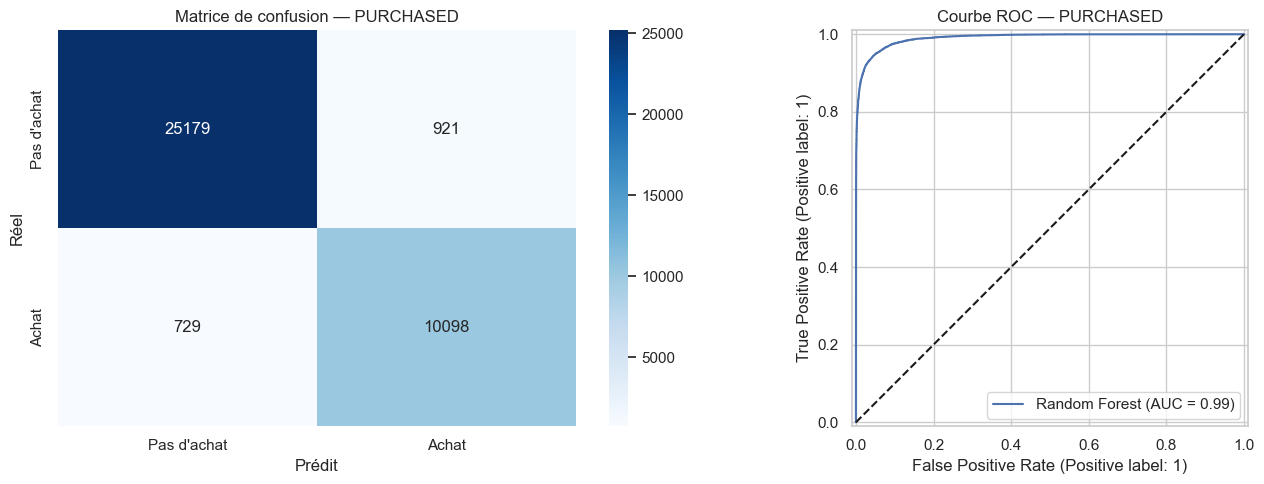

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm_p = confusion_matrix(y_test_p, y_pred_p)
sns.heatmap(cm_p, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Pas d'achat", 'Achat'],
            yticklabels=["Pas d'achat", 'Achat'], ax=axes[0])
axes[0].set_title('Matrice de confusion — PURCHASED')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Courbe ROC
RocCurveDisplay.from_predictions(y_test_p, y_proba_p, ax=axes[1], name='Random Forest')
axes[1].set_title('Courbe ROC — PURCHASED')
axes[1].plot([0,1],[0,1],'k--', label='Aléatoire')

plt.tight_layout()
plt.show()

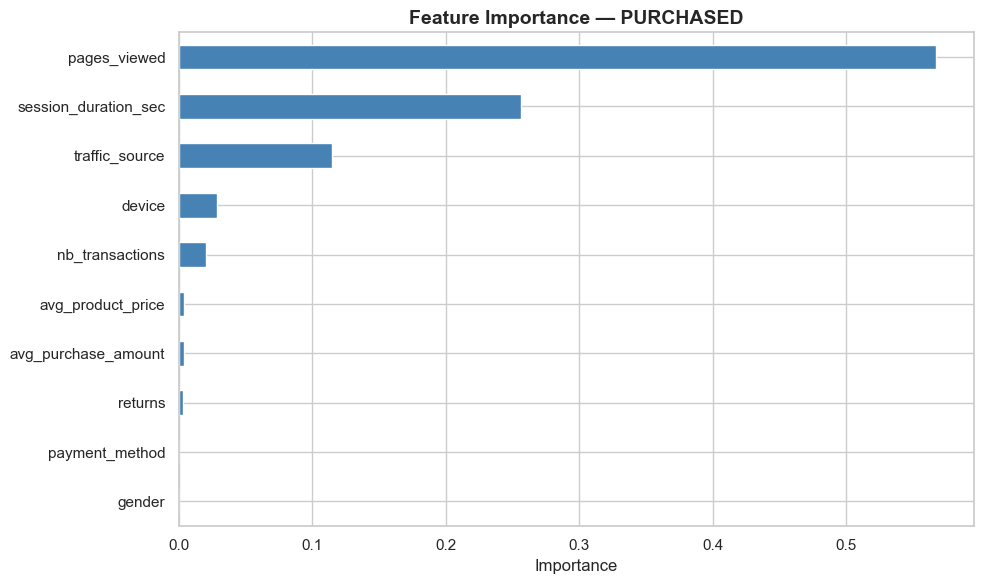

In [ ]:
importances_p = pd.Series(rf_p.feature_importances_, index=features_p).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_p.plot(kind='barh', color='steelblue')
plt.title('Feature Importance — PURCHASED', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## MODÈLE 2 — Prédiction du Churn (CHURN)

**Question :** Ce client va-t-il partir ?

Le churn est défini par les **activités réelles** du client :
- Dernière visite > 270 jours **ET**
- Dernier achat > 270 jours

In [ ]:
# Variables explicatives — comportement du client sur le site
features_c = [
    'nb_sessions',            # nb de visites
    'avg_duration_sec',       # durée moyenne des sessions
    'avg_pages_viewed',       # pages vues en moyenne
    'nb_purchases_traffic',   # nb d'achats depuis le trafic
    'nb_cart_abandoned',      # nb d'abandons de panier
    'taux_achat_session',     # % sessions avec achat
    'taux_abandon_session',   # % sessions avec abandon
    'nb_transactions',        # nb total de transactions
    'avg_purchase_amount',    # montant moyen
    'returns',                # taux de retour
    'gender',
    'payment_method',
    'main_traffic_source',
    'main_device'
]
target_c = 'churn'

# Garder uniquement les colonnes disponibles
features_c = [f for f in features_c if f in df_churn.columns]

df_c = df_churn[features_c + [target_c]].copy()

# Encodage des variables catégorielles
cat_cols_c = ['gender', 'payment_method', 'main_traffic_source', 'main_device']
cat_cols_c = [c for c in cat_cols_c if c in df_c.columns]
le2 = LabelEncoder()
for col in cat_cols_c:
    df_c[col] = df_c[col].fillna('Unknown')
    df_c[col] = le2.fit_transform(df_c[col].astype(str))

df_c = df_c.dropna()
print(f'Shape après nettoyage : {df_c.shape}')
print(f'Taux de churn         : {df_c[target_c].mean():.1%}')

Shape après nettoyage : (48615, 15)
Taux de churn         : 57.5%


In [ ]:
X_c = df_c[features_c]
y_c = df_c[target_c]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c, y_c, test_size=0.2, random_state=42, stratify=y_c
)
print(f'Train : {X_train_c.shape} | Test : {X_test_c.shape}')

rf_c = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_c.fit(X_train_c, y_train_c)
print('Modèle CHURN entraîné ')

Train : (38892, 14) | Test : (9723, 14)
Modèle CHURN entraîné 


In [ ]:
y_pred_c  = rf_c.predict(X_test_c)
y_proba_c = rf_c.predict_proba(X_test_c)[:, 1]

print('=== Classification Report — CHURN ===')
print(classification_report(y_test_c, y_pred_c, target_names=['Actif', 'Churné']))
print(f'ROC-AUC Score : {roc_auc_score(y_test_c, y_proba_c):.4f}')

cv_scores_c = cross_val_score(rf_c, X_c, y_c, cv=5, scoring='roc_auc', n_jobs=-1)
print(f'Cross-validation AUC : {cv_scores_c.mean():.4f} (+/- {cv_scores_c.std():.4f})')

=== Classification Report — CHURN ===
              precision    recall  f1-score   support

       Actif       0.51      0.58      0.54      4135
      Churné       0.66      0.59      0.62      5588

    accuracy                           0.59      9723
   macro avg       0.58      0.59      0.58      9723
weighted avg       0.60      0.59      0.59      9723

ROC-AUC Score : 0.6169
Cross-validation AUC : 0.6208 (+/- 0.0082)


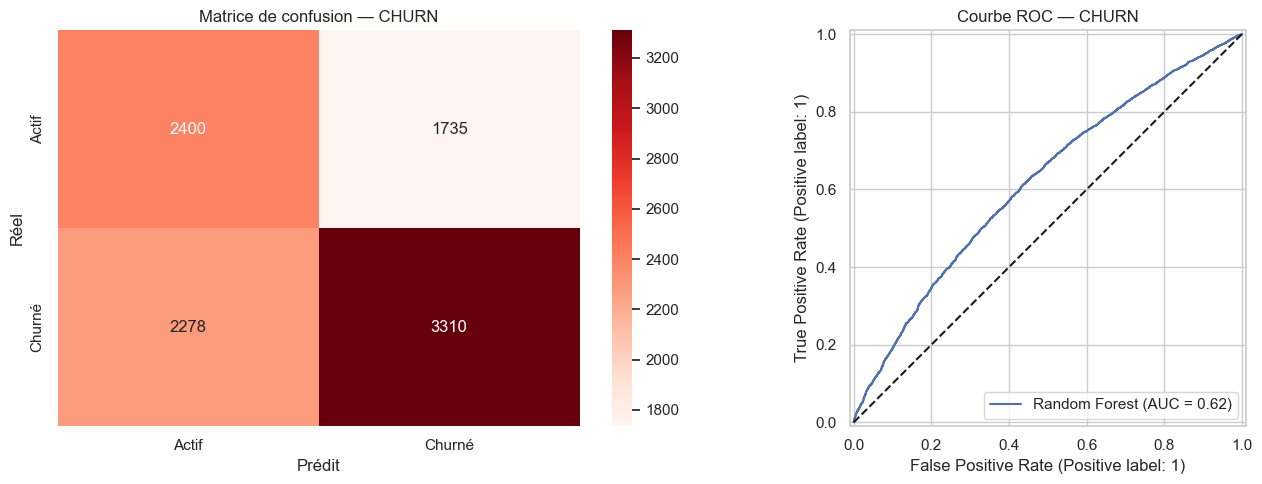

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matrice de confusion
cm_c = confusion_matrix(y_test_c, y_pred_c)
sns.heatmap(cm_c, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Actif', 'Churné'],
            yticklabels=['Actif', 'Churné'], ax=axes[0])
axes[0].set_title('Matrice de confusion — CHURN')
axes[0].set_ylabel('Réel')
axes[0].set_xlabel('Prédit')

# Courbe ROC
RocCurveDisplay.from_predictions(y_test_c, y_proba_c, ax=axes[1], name='Random Forest')
axes[1].set_title('Courbe ROC — CHURN')
axes[1].plot([0,1],[0,1],'k--', label='Aléatoire')

plt.tight_layout()
plt.show()

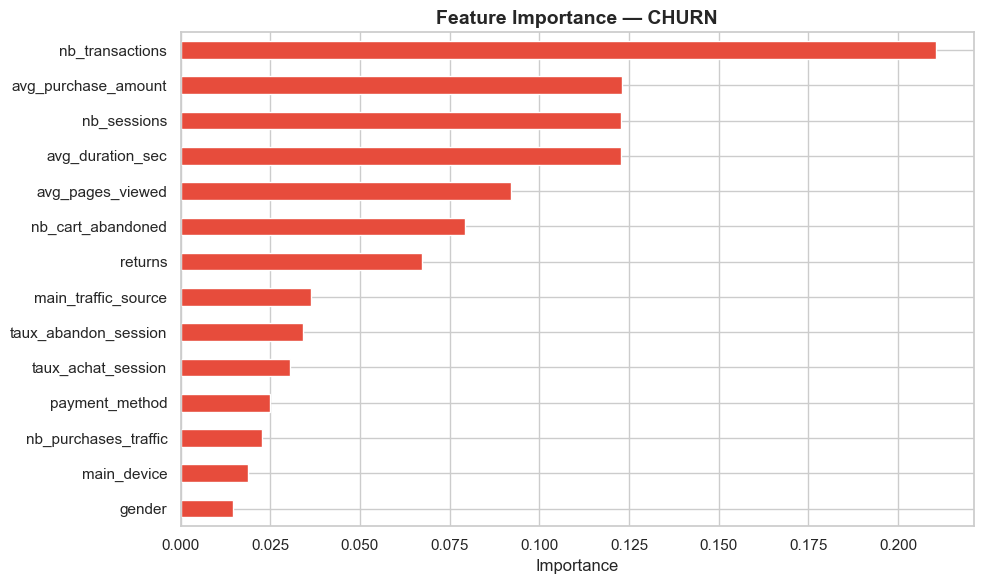

In [ ]:
importances_c = pd.Series(rf_c.feature_importances_, index=features_c).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances_c.plot(kind='barh', color='#e74c3c')
plt.title('Feature Importance — CHURN', fontsize=14, fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

---
## RÉSUMÉ — Liste des clients à risque de churn

In [ ]:
# Probabilité de churn pour chaque client
proba_churn = rf_c.predict_proba(X_c)[:, 1]

df_risque = df_churn.loc[df_c.index, ['customer_id', 'jours_depuis_visite', 'jours_depuis_achat',
                                       'nb_sessions', 'nb_transactions', 'churn']].copy()
df_risque['proba_churn'] = proba_churn
df_risque['risque'] = pd.cut(proba_churn,
                              bins=[0, 0.3, 0.6, 1.0],
                              labels=['Faible', 'Modéré', 'Élevé'])

df_risque = df_risque.sort_values('proba_churn', ascending=False)

print('Top 10 clients les plus à risque de churn :')
display(df_risque.head(10))

print('\nRépartition par niveau de risque :')
print(df_risque['risque'].value_counts())

Top 10 clients les plus à risque de churn :


,customer_id,jours_depuis_visite,jours_depuis_achat,nb_sessions,nb_transactions,churn,proba_churn,risque
46097,46410,547.0,547,1.0,1,1,0.917964,Élevé
25402,25564,236.0,236,1.0,2,1,0.911241,Élevé
40215,40487,1298.0,746,1.0,2,1,0.910267,Élevé
12047,12124,1001.0,283,1.0,2,1,0.902309,Élevé
41097,41376,544.0,544,1.0,2,1,0.902269,Élevé
31960,32170,416.0,416,1.0,2,1,0.900955,Élevé
5224,5252,218.0,218,1.0,2,1,0.896640,Élevé
10728,10795,827.0,826,1.0,1,1,0.895471,Élevé
12151,12230,639.0,638,1.0,2,1,0.894006,Élevé
2506,2518,424.0,176,1.0,2,1,0.888450,Élevé



Répartition par niveau de risque :
risque
Modéré    37486
Élevé     10449
Faible      680
Name: count, dtype: int64


In [ ]:
import os
os.makedirs('dataset/cleaned', exist_ok=True)
df_risque.to_csv('dataset/cleaned/clients_risque_churn.csv', index=False)
print('Fichier clients_risque_churn.csv sauvegardé ')
print('Ce fichier peut être importé dans Power BI pour visualiser les clients à risque.')

Fichier clients_risque_churn.csv sauvegardé 
Ce fichier peut être importé dans Power BI pour visualiser les clients à risque.
